# Exercice 3 - Remplacez la Q-table par un cerveau neuronal (DQN)

La Q-table de l'exercice 2 ne peut pas s'appliquer à CartPole : l'espace d'observation est continu, donc on ne peut pas avoir une ligne par état. La solution : remplacer la table par un **réseau de neurones** qui approxime la fonction Q.

C'est le principe du **Deep Q-Network (DQN)**. On l'implémente de deux façons :

1. **Manuellement avec PyTorch** — pour comprendre les mécanismes internes
2. **Avec Stable-Baselines3** — pour voir comment on travaille en pratique


## Étape 1 : Construire les briques du DQN

Le DQN repose sur deux composants clés au-delà du réseau de neurones :

- **Experience Replay** : au lieu d'apprendre à chaque pas, on stocke les transitions dans un buffer et on tire des batchs aléatoires. Cela casse les corrélations temporelles et stabilise l'apprentissage.
- **Target Network** : un second réseau (copie du premier) dont les poids sont figés pendant quelques épisodes. Il sert à calculer les valeurs Q cibles, ce qui évite que la cible bouge en même temps que l'estimation — une source d'instabilité majeure.


In [1]:
import collections
import random

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


In [2]:
class DQN(nn.Module):
    """Réseau de neurones qui approxime la fonction Q."""

    def __init__(self, n_observations, n_actions):
        super().__init__()
        # 3 couches fully-connected : entrée → 128 → 128 → sortie
        # La sortie a autant de neurones que d'actions possibles :
        # chaque neurone prédit la valeur Q d'une action.
        self.fc1 = nn.Linear(n_observations, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, n_actions)

    def forward(self, x):
        # ReLU : fonction d'activation qui met à zéro les valeurs négatives.
        # Elle introduit la non-linéarité nécessaire pour approximer des fonctions complexes.
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(
            x
        )  # pas d'activation sur la dernière couche : on veut des valeurs Q brutes


class ReplayBuffer:
    """Stocke les transitions passées pour un apprentissage par batchs aléatoires."""

    def __init__(self, capacity):
        # deque avec maxlen : quand le buffer est plein, les transitions les plus anciennes
        # sont automatiquement supprimées pour faire place aux nouvelles.
        self.buffer = collections.deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)

    def __len__(self):
        return len(self.buffer)


# Vérification
env_test = gym.make("CartPole-v1")
n_obs = env_test.observation_space.shape[0]  # 4 valeurs continues
n_act = env_test.action_space.n  # 2 actions
env_test.close()

test_net = DQN(n_obs, n_act)
print("Architecture du DQN :")
print(test_net)

Architecture du DQN :
DQN(
  (fc1): Linear(in_features=4, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=2, bias=True)
)


## Étape 2 : Entraîner le DQN manuellement avec PyTorch

Cette boucle est fournie à titre pédagogique pour comprendre comment fonctionne le DQN de l'intérieur. Elle s'articule autour de cinq blocs à repérer dans le code ci-dessous :

**1. Sélection d'action (epsilon-greedy)**
Même principe qu'en exercice 2 : on tire un nombre aléatoire. S'il est sous epsilon, on explore (action aléatoire). Sinon, on passe l'observation dans `policy_net` et on prend l'action avec la Q-value maximale.

**2. Stockage de la transition**
Après chaque pas, on enregistre le tuple `(état, action, récompense, état_suivant, terminé)` dans le `ReplayBuffer`. On n'apprend pas immédiatement — on accumule d'abord de l'expérience.

**3. La fonction `optimize_model()` — c'est ici que l'apprentissage a lieu**

- On tire un batch aléatoire du buffer (casse les corrélations temporelles)
- `policy_net` prédit les Q-values des actions effectivement choisies : `.gather(1, actions)` sélectionne la valeur de l'action prise parmi toutes les actions possibles
- `target_net` estime la meilleure Q-value future : `target_net(next_states).max(1)[0]`
- On applique la formule de Bellman pour calculer la valeur cible
- La **Huber loss** (`smooth_l1`) mesure l'écart entre prédiction et cible — on minimise cet écart avec `loss.backward()` + `optimizer.step()`

**4. Points de vigilance sur les tenseurs PyTorch**

- `.unsqueeze(1)` transforme un vecteur `(64,)` en matrice `(64, 1)` — nécessaire pour `.gather()`
- `torch.no_grad()` désactive le calcul du gradient pour le target_net : on ne veut pas l'entraîner, seulement l'utiliser pour calculer les cibles
- `(1 - dones)` annule la valeur future si l'épisode est terminé : un état terminal n'a pas de suite

**5. Mise à jour du target_net**
Tous les `TARGET_UPDATE_FREQ` épisodes, on copie les poids du `policy_net` vers le `target_net` avec `load_state_dict()`. Entre deux mises à jour, la cible reste stable — c'est le cœur de l'astuce DQN.


In [3]:
# --- Hyperparamètres ---
BATCH_SIZE = 64
GAMMA = 0.99
EPSILON = 1.0
EPSILON_MIN = 0.05
EPSILON_DECAY = 0.995
LEARNING_RATE = 1e-3
BUFFER_SIZE = 10000
TARGET_UPDATE_FREQ = 10  # tous les combien d'épisodes on copie policy_net → target_net
NB_EPISODES = 300

In [4]:
env = gym.make("CartPole-v1")
n_observations = env.observation_space.shape[0]
n_actions = env.action_space.n

# policy_net : le réseau qu'on entraîne à chaque étape
# target_net : sa copie figée, utilisée uniquement pour calculer les cibles
policy_net = DQN(n_observations, n_actions)
target_net = DQN(n_observations, n_actions)
target_net.load_state_dict(policy_net.state_dict())  # même poids au départ
target_net.eval()  # target_net ne s'entraîne jamais directement

optimizer = optim.Adam(policy_net.parameters(), lr=LEARNING_RATE)
replay_buffer = ReplayBuffer(BUFFER_SIZE)


def optimize_model():
    """Tire un batch du buffer et effectue une étape de gradient sur le policy_net."""
    if len(replay_buffer) < BATCH_SIZE:
        return  # pas assez d'expériences accumulées pour apprendre

    batch = replay_buffer.sample(BATCH_SIZE)
    # On décompresse le batch en listes séparées puis on convertit en tenseurs PyTorch
    states, actions, rewards, next_states, dones = zip(*batch)

    states = torch.FloatTensor(np.array(states))
    actions = torch.LongTensor(actions).unsqueeze(1)  # (batch, 1) pour gather
    rewards = torch.FloatTensor(rewards)
    next_states = torch.FloatTensor(np.array(next_states))
    dones = torch.FloatTensor(dones)

    # Valeurs Q prédites par policy_net pour les actions effectivement choisies.
    # .gather(1, actions) sélectionne la valeur Q de l'action prise parmi les 2 disponibles.
    q_values = policy_net(states).gather(1, actions).squeeze(1)

    # Valeurs Q cibles calculées par target_net (poids figés = cible stable).
    # Pour un état terminal (done=1), la valeur future est 0 : il n'y a pas de suite.
    with torch.no_grad():
        next_q_values = target_net(next_states).max(1)[0]
        target_q_values = rewards + GAMMA * next_q_values * (1 - dones)

    # Huber loss (smooth_l1) : comme MSE mais moins sensible aux grandes erreurs
    loss = F.smooth_l1_loss(q_values, target_q_values)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


# --- Boucle d'entraînement ---
epsilon = EPSILON
rewards_history = []

for episode in range(NB_EPISODES):
    state, _ = env.reset()
    total_reward = 0
    terminated = False
    truncated = False

    while not terminated and not truncated:
        # Epsilon-greedy
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                # On passe l'observation dans le réseau et on prend l'action avec la Q-value max
                action = (
                    policy_net(torch.FloatTensor(state).unsqueeze(0)).argmax().item()
                )

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        replay_buffer.push(state, action, reward, next_state, float(done))
        state = next_state
        total_reward += reward

        optimize_model()

    rewards_history.append(total_reward)
    epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)

    # Mise à jour périodique : on copie les poids du policy_net vers le target_net
    if episode % TARGET_UPDATE_FREQ == 0:
        target_net.load_state_dict(policy_net.state_dict())

    if episode % 50 == 0:
        moyenne = np.mean(rewards_history[-50:])
        print(
            f"Épisode {episode:3d} — récompense moyenne (50 derniers) : {moyenne:.1f}"
        )

env.close()
print("\nEntraînement terminé.")

Épisode   0 — récompense moyenne (50 derniers) : 13.0
Épisode  50 — récompense moyenne (50 derniers) : 22.5
Épisode 100 — récompense moyenne (50 derniers) : 40.1
Épisode 150 — récompense moyenne (50 derniers) : 55.9
Épisode 200 — récompense moyenne (50 derniers) : 38.5
Épisode 250 — récompense moyenne (50 derniers) : 26.1

Entraînement terminé.


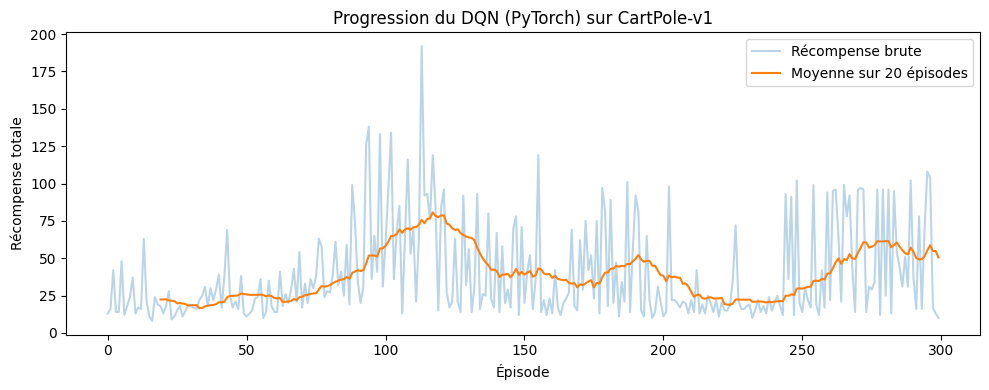

In [5]:
# Courbe de progression lissée sur une fenêtre de 20 épisodes
window = 20
smoothed = np.convolve(rewards_history, np.ones(window) / window, mode="valid")

plt.figure(figsize=(10, 4))
plt.plot(rewards_history, alpha=0.3, label="Récompense brute")
plt.plot(
    range(window - 1, len(rewards_history)),
    smoothed,
    label=f"Moyenne sur {window} épisodes",
)
plt.xlabel("Épisode")
plt.ylabel("Récompense totale")
plt.title("Progression du DQN (PyTorch) sur CartPole-v1")
plt.legend()
plt.tight_layout()
plt.show()

## Étape 3 : Entraîner un DQN avec Stable-Baselines3

Toute la complexité de l'étape 2 (ReplayBuffer, target network, gestion des tenseurs...) est encapsulée en quelques lignes avec SB3. C'est ce qu'on utilise en pratique.

`total_timesteps` correspond au nombre **d'interactions avec l'environnement** (pas au nombre d'épisodes). Avec CartPole, un épisode dure en moyenne 50 à 500 pas selon le niveau de l'agent.


In [6]:
from stable_baselines3 import DQN as DQN_SB3
from stable_baselines3.common.evaluation import evaluate_policy

In [7]:
env_sb3 = gym.make("CartPole-v1")

# MlpPolicy : réseau fully-connected (Multi-Layer Perceptron), adapté aux observations vectorielles
model = DQN_SB3("MlpPolicy", env_sb3, verbose=1)
model.learn(total_timesteps=25000)

print("\nEntraînement SB3 terminé.")

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 30.8     |
|    ep_rew_mean      | 30.8     |
|    exploration_rate | 0.953    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 611      |
|    time_elapsed     | 0        |
|    total_timesteps  | 123      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.551    |
|    n_updates        | 5        |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 26.9     |
|    ep_rew_mean      | 26.9     |
|    exploration_rate | 0.918    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 914      |
|    time_elapsed     | 0        |
|    total_timesteps  | 215      |
| train/              |       

In [8]:
mean_reward, std_reward = evaluate_policy(model, env_sb3, n_eval_episodes=100)
print(f"Récompense moyenne sur 100 épisodes : {mean_reward:.1f} ± {std_reward:.1f}")

model.save("dqn_cartpole")
print("Modèle sauvegardé : dqn_cartpole.zip")

env_sb3.close()

Récompense moyenne sur 100 épisodes : 9.4 ± 0.8
Modèle sauvegardé : dqn_cartpole.zip


/home/clement/Openclassrooms/Livrables/astro-dynamics/.venv/lib/python3.12/site-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(
